# REDOX PROBE PROTOTYPE - Nitrate Reduction Comparisons (v3)

## Introduction
This notebook allows for a systematic comparison of nitrate reduction/removal criteria against multiple different redox boundary definitions:
1. **Redox Primary**: The first major drop in redox potential (Auto_1).
2. **Redox Secondary**: The second major drop in redox potential (Auto_2).
3. **GEUS FRI**: The official GEUS-interpreted First Redox Interface.
4. **Color FRI (With Litho)**: Algorithmic boundary based on sediment color and lithology factors (Kim et al. 2025).
5. **Color FRI (No Litho)**: Algorithmic boundary based on sediment color only, ignoring lithology penalties.

## Analytical Criteria (v2 Logic)
- **N-reduction**: Requires a baseline > 10 mg/L above the interface and a 50% drop within the window.
- **No nitrate**: Requires concentration < 1.0 mg/L within the window and stability (staying low) deeper in the log.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# ==========================================
# CONFIGURATION & PARAMETERS
# ==========================================
BOUNDARY_TO_TEST = 'redox_primary' # Options: 'redox_primary', 'redox_secondary', 'geus_fri', 'color_with_litho', 'color_without_litho'

VALIDATION_PARAMS = {
    'DISTANCE_1': 1.0,
    'DISTANCE_2': 2.0,
    'REDUCTION_RATIO': 0.7,
    'NO_NITRATE_THRESHOLD': 5,
    'MIN_BASELINE_FOR_REDUCTION': 3.0,
    'STABILITY_MARGIN': 0.8,
    'EU_LEGISLATION_LIMIT': 50.0,
    'REDUCTION_LOGIC': 'relaxed' # Options: 'strict', 'relaxed', 'both'
}

COLOR_ALGO_CONFIG = {
    'BIN_SIZE_M': 0.2,
    'REDOX_THRESHOLD': 0.1,
    'PERSISTENCE_BINS': 5,
    'DIRECTION': 'top-down',
    'DEPTH_DEPENDENT_MODEL': 'linear'
}

print(f"Testing against BOUNDARY: {BOUNDARY_TO_TEST}")


Testing against BOUNDARY: redox_primary


In [2]:
# --- ID Normalization ---
def normalize_id(row, source):
    loop = str(row['LOOPNr']).strip().upper()
    raw_id = str(row['ID']).strip()
    if source == 'Redox':
        norm = re.sub(r'[a-z]$', '', raw_id, flags=re.IGNORECASE)
        if loop == 'DEMO' and norm.isdigit(): norm = f"D{norm}"
        if loop == 'LOOP4':
            norm = norm.replace('Geological Window-', 'GeoW-').replace('interglacial sand-', 'IS-').replace('meltwater sand-', 'MS-').replace('Til layer-', 'TL-')
        return norm
    elif source == 'Geochem':
        if loop in ['LOOP2', 'LOOP3', 'LOOP6']: return re.sub(r'^P', '', raw_id)
        return raw_id

# --- Load Data ---
df_algo = pd.read_csv('../Interface_Detection/Extracted_Advanced_Interfaces.csv')
df_geochem = pd.read_csv('../Python_Redox_Geochemistry/Geochemistry/Master_Geochemistry.csv')
df_metadata = pd.read_csv('../Python_Redox_Geochemistry/Borehole_Metadata.csv')
df_litho = pd.read_csv('../Python_Redox_Geochemistry/Lithology/Master_Lithology.csv', encoding='iso-8859-1')
df_cmap = pd.read_csv('../Python_Redox_Geochemistry/Lithology/Color_mapping.csv', encoding='iso-8859-1')
df_lmap = pd.read_csv('../Python_Redox_Geochemistry/Lithology/Lithology_mapping.csv', encoding='iso-8859-1')

df_algo['Norm_ID'] = df_algo.apply(lambda row: normalize_id(row, 'Redox'), axis=1)
df_geochem['Norm_ID'] = df_geochem.apply(lambda row: normalize_id(row, 'Geochem'), axis=1)
df_metadata['Norm_ID'] = df_metadata.apply(lambda row: normalize_id(row, 'Geochem'), axis=1)
df_litho['Norm_ID'] = df_litho.apply(lambda row: normalize_id(row, 'Geochem'), axis=1)

# Consensus Redox Interfaces
df_consensus = df_algo.groupby(['LOOPNr', 'Norm_ID'])[['Main_Drop_Z', 'Sec_Drop_Z']].mean().reset_index()

# Clean Nitrate
for col in ['NO₃⁻ [mg/L]', 'GW_NO₃⁻ [mg/L]']:
    if col in df_geochem.columns: df_geochem[col] = pd.to_numeric(df_geochem[col], errors='coerce')
df_geochem['Nitrate'] = df_geochem['NO₃⁻ [mg/L]'].fillna(df_geochem.get('GW_NO₃⁻ [mg/L]', np.nan))
df_geochem = df_geochem.dropna(subset=['Depth (m)', 'Nitrate'])


In [3]:
# --- Color Interface Calculation Logic ---
table4_params = {
    'Grayish brown': (50.8, 76.6), 'Gray': (40.1, 55.6), 'Light brownish gray': (41.8, 59.9),
    'Pale brown': (39.2, 46.2), 'Light yellowish brown': (46.3, 51.6), 'Dark grayish brown': (34.1, 55.9)
}

def calculate_base_pox(z, color_en, raw_pox, logic):
    logic = str(logic).strip()
    if logic == 'P_ox=1': return 1.0
    if logic == 'P_ox=0': return 0.0
    if logic == 'P_ox=0.35': return 0.35
    try:
        raw_pox_val = float(raw_pox) if pd.notna(raw_pox) else 0.0
    except:
        raw_pox_val = 0.0
    match = re.search(r'([0-9.]+) down to ([0-9]+)m', logic)
    if match: return float(match.group(1)) if z <= float(match.group(2)) else 0.0
    if 'Table 4' in logic or 'Depth dependent' in logic:
        key = str(color_en).strip()
        if key == 'Dark grayish brown' and raw_pox_val >= 0.1: key = 'Grayish brown'
        if key not in table4_params:
            if 'Gray' in key: key = 'Gray'
            elif 'brownish gray' in key: key = 'Light brownish gray'
            elif 'grayish brown' in key: key = 'Grayish brown'
            else: return 0.0
        z_01, z_0 = table4_params.get(key, (0, 0))
        if z_01 == 0 or z >= z_0: return 0.0
        slope = -0.1 / (z_0 - z_01)
        p = 0.1 + slope * (z - z_01)
        return max(0.0, min(1.0, p))
    return float(raw_pox) if pd.notna(raw_pox) and str(raw_pox).replace('.','').isdigit() else 0.0

def compute_interval_pox(row, df_cmap, df_lmap, apply_litho):
    z = (row['Depth_From'] + row['Depth_To']) / 2.0
    cmap_row = df_cmap[df_cmap['Danish Color'].str.lower() == str(row['Color_Description']).lower()]
    lmap_row = df_lmap[df_lmap['Lithology'].str.lower() == str(row['Lithology']).lower()]
    if cmap_row.empty or lmap_row.empty: return np.nan
    base_pox = calculate_base_pox(z, cmap_row.iloc[0]['English Equivalent'], cmap_row.iloc[0]['Raw Oxic Fraction'], cmap_row.iloc[0]['Pox Definition / Logic'])
    if not apply_litho: return base_pox
    factor_str = str(lmap_row.iloc[0]['Factor'])
    if 'Ignore' in factor_str: return np.nan
    factor = 1.0 if 'unless P_ox=1' in factor_str and base_pox == 1.0 else (0.0 if 'unless P_ox=1' in factor_str else float(factor_str) if factor_str.replace('.','').isdigit() else 1.0)
    return base_pox * factor

def get_color_fri(loop, norm_id, apply_litho):
    sub = df_litho[(df_litho["LOOPNr"] == loop) & (df_litho["Norm_ID"] == norm_id)].copy()
    if sub.empty: return np.nan
    sub["P_ox"] = sub.apply(lambda r: compute_interval_pox(r, df_cmap, df_lmap, apply_litho), axis=1)
    sub = sub.dropna(subset=["P_ox"])
    if sub.empty: return np.nan
    max_depth = int(np.ceil(sub["Depth_To"].max()))
    bins = np.round(np.arange(0, max_depth + 1, COLOR_ALGO_CONFIG["BIN_SIZE_M"]), 3)
    binned_pox = []
    for i in range(len(bins)-1):
        b_start, b_end = bins[i], bins[i+1]
        w_sum, t_len = 0, 0
        for _, row in sub.iterrows():
            overlap = min(b_end, row["Depth_To"]) - max(b_start, row["Depth_From"])
            if overlap > 0:
                w_sum += overlap * row["P_ox"]; t_len += overlap
        binned_pox.append(w_sum / t_len if t_len > 0 else np.nan)
    for i in range(len(binned_pox) - COLOR_ALGO_CONFIG["PERSISTENCE_BINS"] + 1):
        if not np.isnan(binned_pox[i:i+5]).any() and np.all(np.array(binned_pox[i:i+5]) <= COLOR_ALGO_CONFIG["REDOX_THRESHOLD"]):
            return bins[i]
    return np.nan


In [4]:
# --- Boundary Assignment ---
boreholes = df_geochem[['LOOPNr', 'Norm_ID']].drop_duplicates()
boundary_data = []

for _, bh in boreholes.iterrows():
    loop, norm_id = bh['LOOPNr'], bh['Norm_ID']
    
    # Get Primary/Secondary from consensus
    redox_row = df_consensus[(df_consensus['LOOPNr'] == loop) & (df_consensus['Norm_ID'] == norm_id)]
    p_redox = redox_row['Main_Drop_Z'].iloc[0] if not redox_row.empty else np.nan
    s_redox = redox_row['Sec_Drop_Z'].iloc[0] if not redox_row.empty else np.nan
    
    # Get GEUS FRI from metadata
    meta_row = df_metadata[(df_metadata['LOOPNr'] == loop) & (df_metadata['Norm_ID'] == norm_id)]
    g_fri = pd.to_numeric(meta_row['GEUS_FRI'].iloc[0], errors='coerce') if not meta_row.empty else np.nan
    
    # Calculate Color FRIs
    c_litho = get_color_fri(loop, norm_id, apply_litho=True)
    c_no_litho = get_color_fri(loop, norm_id, apply_litho=False)
    
    # Choose the active boundary
    if BOUNDARY_TO_TEST == 'redox_primary': boundary_z = p_redox
    elif BOUNDARY_TO_TEST == 'redox_secondary': boundary_z = s_redox
    elif BOUNDARY_TO_TEST == 'geus_fri': boundary_z = g_fri
    elif BOUNDARY_TO_TEST == 'color_with_litho': boundary_z = c_litho
    elif BOUNDARY_TO_TEST == 'color_without_litho': boundary_z = c_no_litho
    else: boundary_z = np.nan
    
    boundary_data.append({
        'LOOPNr': loop, 'Norm_ID': norm_id, 'Boundary_Z': boundary_z,
        'Redox_P': p_redox, 'Redox_S': s_redox, 'GEUS_FRI': g_fri, 'Color_Litho': c_litho, 'Color_NoLitho': c_no_litho
    })

df_boundaries = pd.DataFrame(boundary_data)
df_boundaries = df_boundaries.dropna(subset=['Redox_P'])
df_boundaries = df_boundaries[~((df_boundaries['LOOPNr'] == 'LOOP3') & (df_boundaries['Norm_ID'] == '6'))]
df_boundaries = df_boundaries[~((df_boundaries['LOOPNr'] == 'LOOP6') & (df_boundaries['Norm_ID'] == '2'))]
df_boundaries = df_boundaries[~((df_boundaries['LOOPNr'] == 'LOOP6') & (df_boundaries['Norm_ID'].str.lower() == '2a'))]

df_merged = pd.merge(df_boundaries, df_geochem[['LOOPNr', 'Norm_ID', 'Depth (m)', 'Nitrate']], on=['LOOPNr', 'Norm_ID'])


In [5]:
# --- Validation Logic (v2.1) ---
results = []
P = VALIDATION_PARAMS

for (loop, norm_id), group in df_merged.groupby(['LOOPNr', 'Norm_ID']):
    bz = group['Boundary_Z'].iloc[0]
    group = group.sort_values('Depth (m)')
    depths, nitrates = group['Depth (m)'].values, group['Nitrate'].values
    
    # Baseline - calculate above the current boundary if it exists, else use global max
    if pd.notna(bz):
        above_idx = depths < bz
        baseline_n = np.max(nitrates[above_idx]) if np.any(above_idx) else 0.0
    else:
        baseline_n = np.max(nitrates) if len(nitrates) > 0 else 0.0

    logic = P.get('REDUCTION_LOGIC', 'strict')

    # User override: LOOP2 1 is excluded completely
    if loop == 'LOOP2' and str(norm_id) == '1':
        if pd.isna(bz):
            res = {'Borehole': f"{loop} {norm_id}", 'Zero 1m': '(No N reduction)', 'Zero 2m': '(No N reduction)', 'Notes': 'Excluded (No N reduction)'}
            if logic == 'both': res.update({'N-red 1m': '(No N reduction)', 'N-red 2m': '(No N reduction)', 'N-red 1m (Rel)': '(No N reduction)', 'N-red 2m (Rel)': '(No N reduction)'})
            else: res.update({'N-red 1m': '(No N reduction)', 'N-red 2m': '(No N reduction)'})
        else:
            res = {'Borehole': f"{loop} {norm_id}", 'Zero 1m': '-', 'Zero 2m': '-', 'Notes': 'Fail (No reduction observed in profile)'}
            if logic == 'both': res.update({'N-red 1m': '-', 'N-red 2m': '-', 'N-red 1m (Rel)': '-', 'N-red 2m (Rel)': '-'})
            else: res.update({'N-red 1m': '-', 'N-red 2m': '-'})
        results.append(res)
        continue

    # User override: LOOP2 2A is ALWAYS a FAIL
    if loop == 'LOOP2' and str(norm_id).upper() == '2A':
        if pd.isna(bz):
            res = {'Borehole': f"{loop} {norm_id}", 'Zero 1m': '(No N reduction)', 'Zero 2m': '(No N reduction)', 'Notes': 'Excluded (No N reduction)'}
            if logic == 'both': res.update({'N-red 1m': '(No N reduction)', 'N-red 2m': '(No N reduction)', 'N-red 1m (Rel)': '(No N reduction)', 'N-red 2m (Rel)': '(No N reduction)'})
            else: res.update({'N-red 1m': '(No N reduction)', 'N-red 2m': '(No N reduction)'})
        else:
            res = {'Borehole': f"{loop} {norm_id}", 'Zero 1m': '-', 'Zero 2m': '-', 'Notes': 'Fail (Fluctuating nitrate, no true reduction)'}
            if logic == 'both': res.update({'N-red 1m': '-', 'N-red 2m': '-', 'N-red 1m (Rel)': '-', 'N-red 2m (Rel)': '-'})
            else: res.update({'N-red 1m': '-', 'N-red 2m': '-'})
        results.append(res)
        continue

    if pd.isna(bz):
        note = f'Fail (No {BOUNDARY_TO_TEST} found but reduction exists)'
        res = {'Borehole': f"{loop} {norm_id}", 'Zero 1m': '-', 'Zero 2m': '-', 'Notes': note}
        if logic == 'both':
            res.update({'N-red 1m': '-', 'N-red 2m': '-', 'N-red 1m (Rel)': '-', 'N-red 2m (Rel)': '-'})
        else:
            res.update({'N-red 1m': '-', 'N-red 2m': '-'})
        results.append(res)
        continue
    def check_reduction(win, mode='strict'):
        mask = (depths >= bz - win) & (depths <= bz + win)
        if not np.any(mask):
            if not np.any(depths > bz + win) or not np.any(depths < bz - win):
                return None
            w_min = min(np.interp(bz - win, depths, nitrates), np.interp(bz + win, depths, nitrates))
        else:
            w_min = np.min(nitrates[mask])
        
        if mode == 'relaxed':
            # Relaxed Logic: Ratio drop from OVERALL baseline OR below threshold
            return 'X' if (w_min < P['NO_NITRATE_THRESHOLD'] or w_min <= (1.0 - P['REDUCTION_RATIO']) * baseline_n) else '-'
        else:
            # Strict Logic (v2.1): Interpolated entry, baseline check
            z_entry = bz - win
            n_entry = np.interp(z_entry, depths, nitrates) if z_entry >= np.min(depths) else nitrates[0]
            if baseline_n < P['MIN_BASELINE_FOR_REDUCTION']: return '-'
            # Reject if already dropped substantially (by 50%) before the boundary
            if n_entry < 0.5 * baseline_n and n_entry < 10.0: return '-'
            # Primary decider: Must drop by the specified REDUCTION_RATIO compared to the entry point
            return 'X' if (w_min <= (1.0 - P['REDUCTION_RATIO']) * n_entry) else '-'
        
    def check_no_nitrate(win):
        mask = (depths > bz) & (depths <= bz + win)
        if not np.any(mask):
            if not np.any(depths > bz + win) or not np.any(depths < bz):
                return None
            n_at_win = np.interp(bz + win, depths, nitrates)
            if n_at_win >= P['NO_NITRATE_THRESHOLD']:
                return '-'
            else:
                limit = P['NO_NITRATE_THRESHOLD'] * (1 + P['STABILITY_MARGIN'])
                deeper = depths > bz + win
                return 'X' if not (np.any(deeper) and np.any(nitrates[deeper] > limit)) else '-'
        
        low_ids = np.where(mask & (nitrates < P['NO_NITRATE_THRESHOLD']))[0]
        if len(low_ids) == 0: return '-'
        limit = P['NO_NITRATE_THRESHOLD'] * (1 + P['STABILITY_MARGIN'])
        deeper = depths > depths[low_ids[0]]
        return 'X' if not (np.any(deeper) and np.any(nitrates[deeper] > limit)) else '-'

    logic = P.get('REDUCTION_LOGIC', 'strict')
    res = {'Borehole': f"{loop} {norm_id}", 'Zero 1m': check_no_nitrate(P['DISTANCE_1']) or '(no data)', 'Zero 2m': check_no_nitrate(P['DISTANCE_2']) or '(no data)'}
    
    if logic == 'both':
        res.update({
            'N-red 1m': check_reduction(P['DISTANCE_1'], 'strict') or '-',
            'N-red 2m': check_reduction(P['DISTANCE_2'], 'strict') or '-',
            'N-red 1m (Rel)': check_reduction(P['DISTANCE_1'], 'relaxed') or '-',
            'N-red 2m (Rel)': check_reduction(P['DISTANCE_2'], 'relaxed') or '-'
        })
    else:
        res.update({
            'N-red 1m': check_reduction(P['DISTANCE_1'], logic) or '-',
            'N-red 2m': check_reduction(P['DISTANCE_2'], logic) or '-'
        })
    
    res['Notes'] = f"Baseline ({baseline_n:.1f}) low" if (baseline_n < P['MIN_BASELINE_FOR_REDUCTION'] and logic != 'relaxed') else ""
    results.append(res)

df_results = pd.DataFrame(results)
display(df_results)


,Borehole,Zero 1m,Zero 2m,N-red 1m,N-red 2m,Notes
0,DEMO D6,-,X,X,X,
1,DEMO D7,-,-,-,-,
2,LOOP2 1,-,-,-,-,Fail (No reduction observed in profile)
3,LOOP2 2,X,X,X,X,
4,LOOP2 2A,-,-,-,-,"Fail (Fluctuating nitrate, no true reduction)"
5,LOOP2 3,X,X,X,X,
6,LOOP2 4,-,-,X,X,
7,LOOP3 1,X,X,X,X,
8,LOOP3 2,X,X,X,X,
9,LOOP3 3,-,X,-,X,


### Validation Matrix Heatmap
Visualizing the criteria fulfillment for the selected boundary.

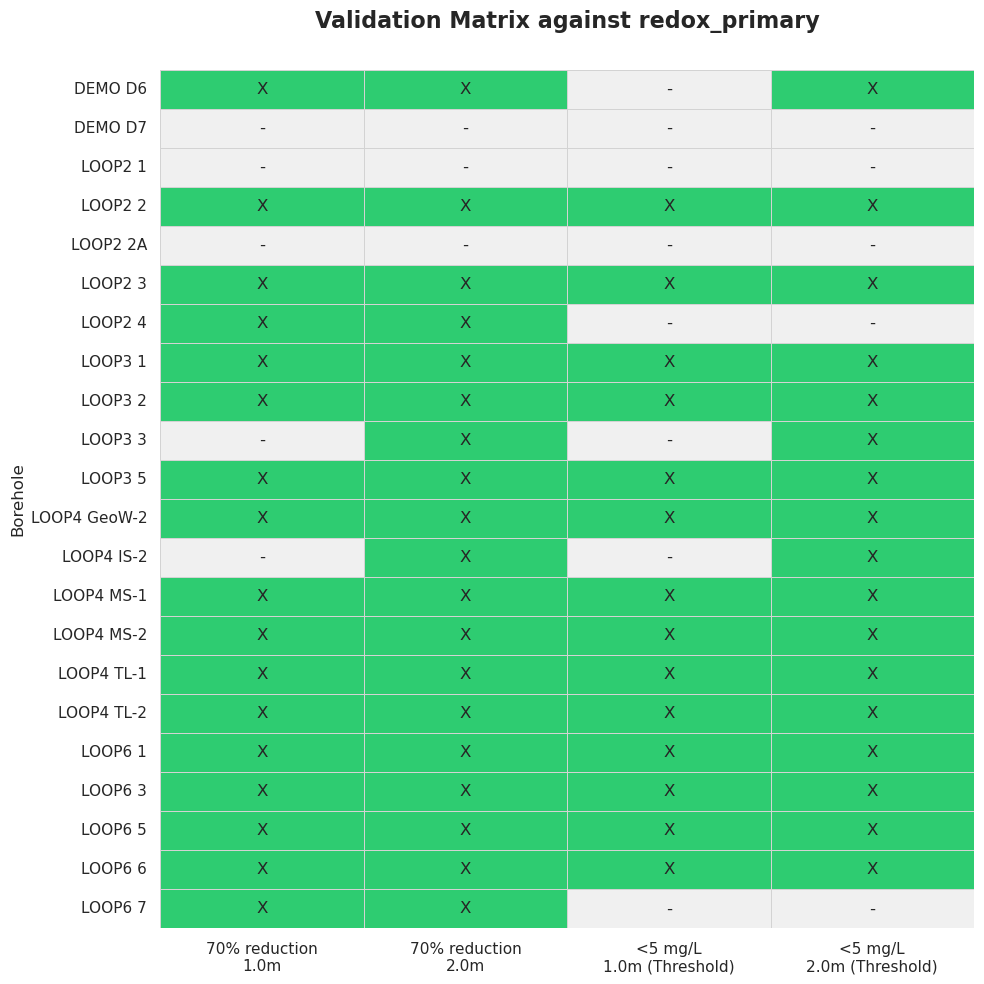

In [6]:
df_heat = df_results.copy().set_index('Borehole')
cols = ['N-red 1m', 'N-red 2m']
if 'N-red 1m (Rel)' in df_results.columns: cols += ['N-red 1m (Rel)', 'N-red 2m (Rel)']
cols += ['Zero 1m', 'Zero 2m']
df_heat = df_heat[cols]
val_map = {'X': 1, '-': 0, '(no data)': -1, '(No N reduction)': -1}
for col in df_heat.columns: df_heat[col] = df_heat[col].map(val_map)
logic_type = VALIDATION_PARAMS.get('REDUCTION_LOGIC', 'strict')
ratio = int(VALIDATION_PARAMS['REDUCTION_RATIO'] * 100)
thresh = VALIDATION_PARAMS['NO_NITRATE_THRESHOLD']
d1 = VALIDATION_PARAMS['DISTANCE_1']
d2 = VALIDATION_PARAMS['DISTANCE_2']
    
if logic_type == 'both':
    title_map = {
        'N-red 1m': f"{ratio}% reduction\n{d1}m (Strict)",
        'N-red 2m': f"{ratio}% reduction\n{d2}m (Strict)",
        'N-red 1m (Rel)': f"{ratio}% reduction\n{d1}m (Relaxed)",
        'N-red 2m (Rel)': f"{ratio}% reduction\n{d2}m (Relaxed)",
        'Zero 1m': f"<{thresh} mg/L\n{d1}m (Threshold)",
        'Zero 2m': f"<{thresh} mg/L\n{d2}m (Threshold)"
    }
else:
    title_map = {
        'N-red 1m': f"{ratio}% reduction\n{d1}m",
        'N-red 2m': f"{ratio}% reduction\n{d2}m",
        'Zero 1m': f"<{thresh} mg/L\n{d1}m (Threshold)",
        'Zero 2m': f"<{thresh} mg/L\n{d2}m (Threshold)"
    }
new_cols = [title_map.get(c, c) for c in df_heat.columns]
df_heat.columns = new_cols
plt.figure(figsize=(10, 10))
sns.heatmap(df_heat, cmap=sns.color_palette(["#f0f0f0", "#cccccc", "#2ecc71"]), cbar=False, linewidths=.5, linecolor='lightgray', annot=df_results.set_index('Borehole')[cols].rename(columns=dict(zip(cols, new_cols))), fmt='')
plt.title(f'Validation Matrix against {BOUNDARY_TO_TEST}', pad=30, size=16, weight='bold')
plt.tight_layout(); plt.show()

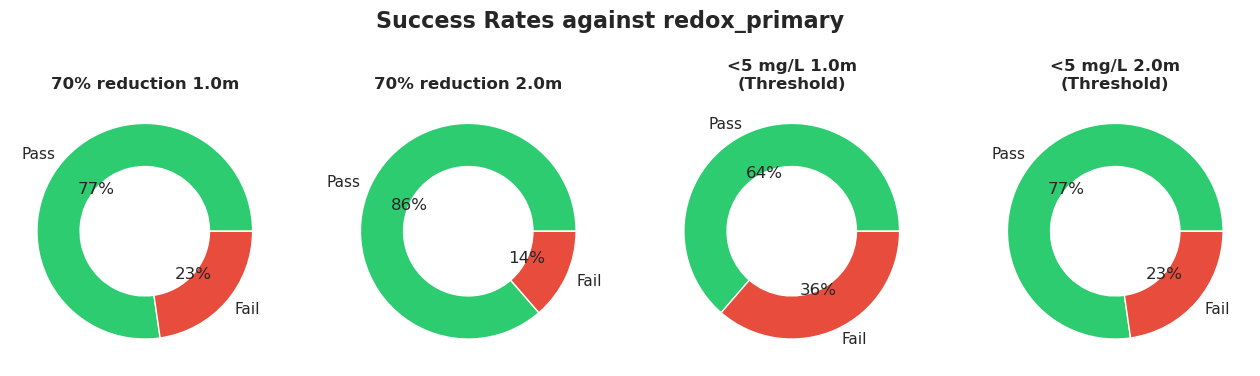

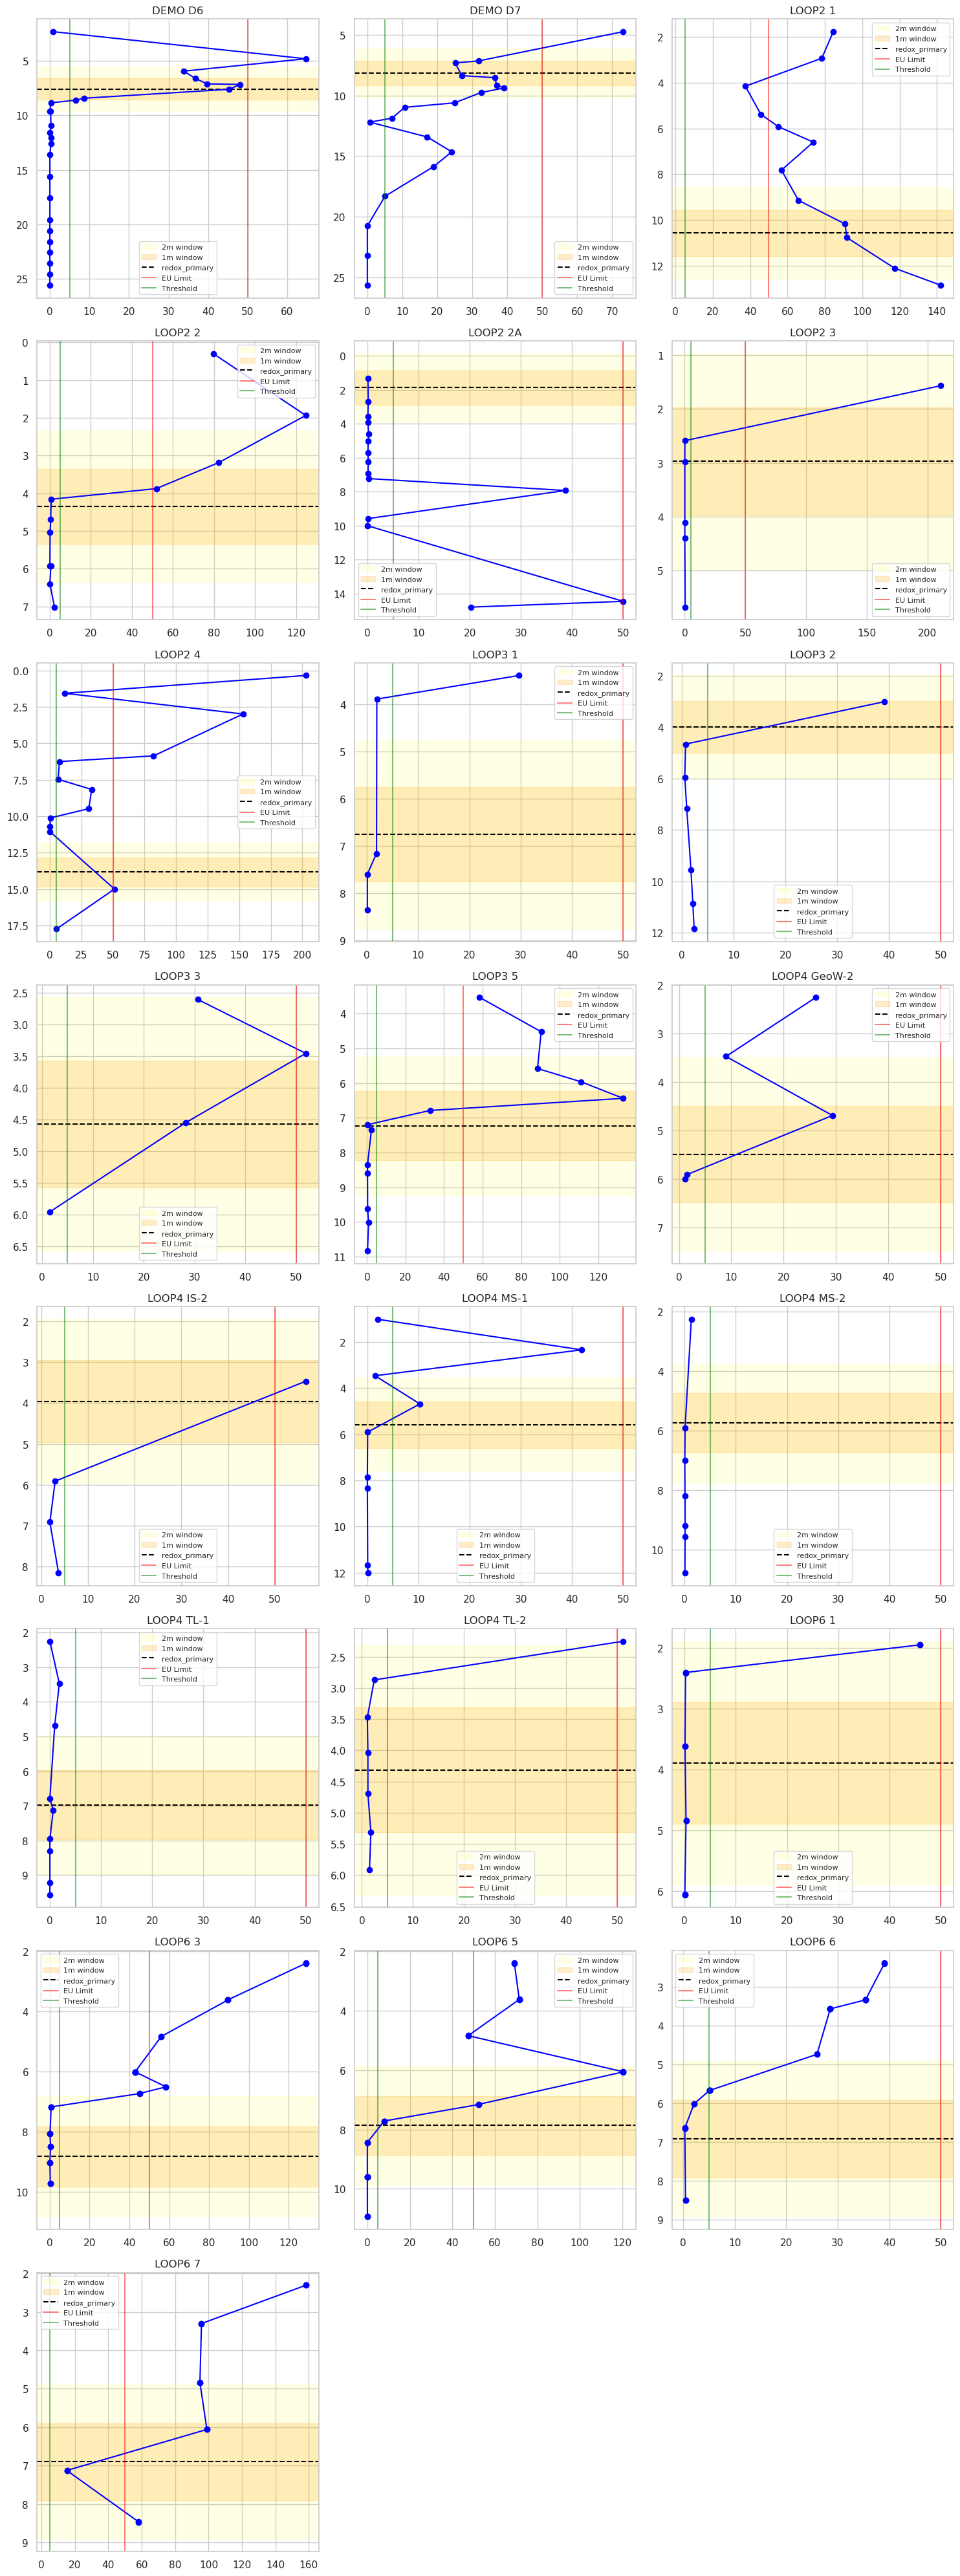

In [7]:
# --- Visualizations ---
eligible = df_results[~df_results['Notes'].str.contains('Excluded', na=False)]
metrics = ['N-red 1m', 'N-red 2m']
if 'N-red 1m (Rel)' in df_results.columns: metrics += ['N-red 1m (Rel)', 'N-red 2m (Rel)']
metrics += ['Zero 1m', 'Zero 2m']
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1: axes = [axes]
for i, m in enumerate(metrics):
    pass_c = (eligible[m] == 'X').sum()
    fail_c = (eligible[m] == '-').sum()
    if pass_c + fail_c > 0:
        axes[i].pie([pass_c, fail_c], labels=['Pass', 'Fail'], colors=['#2ecc71', '#e74c3c'], autopct='%1.0f%%', wedgeprops=dict(width=0.4))
    



    logic_type = VALIDATION_PARAMS.get('REDUCTION_LOGIC', 'strict')
    ratio = int(VALIDATION_PARAMS['REDUCTION_RATIO'] * 100)
    thresh = VALIDATION_PARAMS['NO_NITRATE_THRESHOLD']
    d1 = VALIDATION_PARAMS['DISTANCE_1']
    d2 = VALIDATION_PARAMS['DISTANCE_2']
    
    if logic_type == 'both':
        title_map = {
            'N-red 1m': f"{ratio}% reduction {d1}m\n(Strict)",
            'N-red 2m': f"{ratio}% reduction {d2}m\n(Strict)",
            'N-red 1m (Rel)': f"{ratio}% reduction {d1}m\n(Relaxed)",
            'N-red 2m (Rel)': f"{ratio}% reduction {d2}m\n(Relaxed)",
            'Zero 1m': f"<{thresh} mg/L {d1}m\n(Threshold)",
            'Zero 2m': f"<{thresh} mg/L {d2}m\n(Threshold)"
        }
    else:
        title_map = {
            'N-red 1m': f"{ratio}% reduction {d1}m",
            'N-red 2m': f"{ratio}% reduction {d2}m",
            'Zero 1m': f"<{thresh} mg/L {d1}m\n(Threshold)",
            'Zero 2m': f"<{thresh} mg/L {d2}m\n(Threshold)"
        }
    axes[i].set_title(title_map.get(m, m), weight='bold')
plt.suptitle(f'Success Rates against {BOUNDARY_TO_TEST}', size=16, weight='bold', y=1.05)
plt.show()

# Profiles
sample_bhs = df_results['Borehole'].tolist()
num_bhs = len(sample_bhs)
cols = 3
rows = (num_bhs + cols - 1) // cols
if rows > 0:
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if num_bhs > 1 else [axes]
    for i, bh_name in enumerate(sample_bhs):
        loop, norm_id = bh_name.split(' ')
        group = df_merged[(df_merged['LOOPNr'] == loop) & (df_merged['Norm_ID'] == norm_id)].sort_values('Depth (m)')
        bz = group['Boundary_Z'].iloc[0]
        ax = axes[i]
        if pd.notna(bz):
            ax.axhspan(bz-VALIDATION_PARAMS['DISTANCE_2'], bz+VALIDATION_PARAMS['DISTANCE_2'], color='yellow', alpha=0.1, label='2m window')
            ax.axhspan(bz-VALIDATION_PARAMS['DISTANCE_1'], bz+VALIDATION_PARAMS['DISTANCE_1'], color='orange', alpha=0.2, label='1m window')
            ax.axhline(bz, color='black', linestyle='--', label=BOUNDARY_TO_TEST)
        ax.plot(group['Nitrate'], group['Depth (m)'], marker='o', color='blue')
        ax.axvline(50, color='red', alpha=0.5, label='EU Limit')
        ax.axvline(VALIDATION_PARAMS['NO_NITRATE_THRESHOLD'], color='green', alpha=0.5, label='Threshold')
        ax.set_title(bh_name); ax.invert_yaxis(); ax.legend(fontsize=8)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(); plt.show()
